In [22]:
from Models import aggregate_model, IndividualModel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline

from pathlib import Path
import math

In [23]:
df_fit = pd.read_csv("best_fit_ebm.csv")
df_u25 = pd.read_csv("u25.csv") #ABM 100 simulations

u25_mat = df_u25.pivot(index="id", columns="t", values="population")
u25_mat = u25_mat.sort_index(axis=1)

sims_u25 = u25_mat.to_numpy(dtype=float)

In [24]:
c = df_fit.loc[0, "c"]
m = df_fit.loc[0, "m"]
n = df_fit.loc[0, "n"]
d = df_fit.loc[0, "d"]
k = df_fit.loc[0, "k"]
R = df_fit.loc[0, "R"]
nrmse = df_fit.loc[0, "RMSE_EBM"]

T = 2000
P_0 = 10
s_0 = 0
z = 4

t_ED = np.array([0, 80, 315, 560, 736, 800, 900, 1000, 1280, 1350, 1480], dtype=int)
p_ED = np.array([8, 20, 620, 2200, 2056, 1800, 1500, 1250, 680, 320, 95], dtype=float)

In [25]:
S_ts, P_ts = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
S_ts_EBM = S_ts
P_ts_EBM = P_ts

model_abm = IndividualModel(T, c, m, n, d, k, R, P_0, s_0, z)
model_abm.setup()
model_abm.run()

S_ts_ABM = model_abm.S_ts
P_ts_ABM = model_abm.P_ts

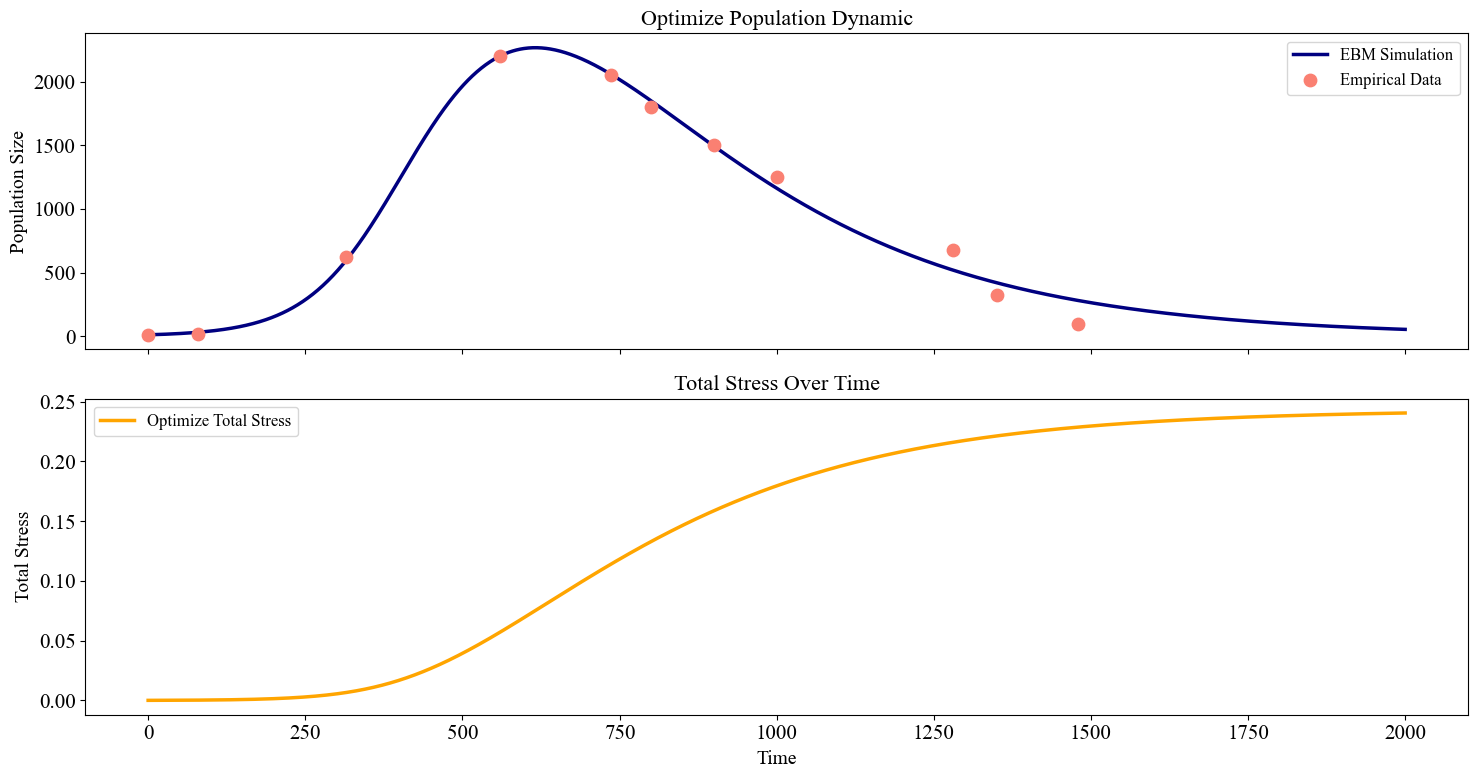

In [26]:
FIGSIZE = (15, 8)
LINEWIDTH = 2.5
MARKER_SIZE = 80
FONT_SIZE = 14

COLOR_EBM = "navy"
COLOR_ED = "salmon"
COLOR_STRESS = "orange"

TITLE_SIZE = 16
LABEL_SIZE = 14
LEGEND_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE
})

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax = axes[0]
ax.plot(P_ts_EBM, label="EBM Simulation", color=COLOR_EBM, linewidth=LINEWIDTH)
ax.scatter(t_ED, p_ED, label="Empirical Data", color=COLOR_ED, s=MARKER_SIZE, zorder=3)
ax.set_ylabel("Population Size")
ax.set_title("Optimize Population Dynamic")
ax.legend()

ax = axes[1]
ax.plot(S_ts_EBM, label="Optimize Total Stress", color=COLOR_STRESS, linewidth=LINEWIDTH)
ax.set_ylabel("Total Stress")
ax.set_xlabel("Time")
ax.set_title("Total Stress Over Time")
ax.legend()

plt.tight_layout()
plt.show()

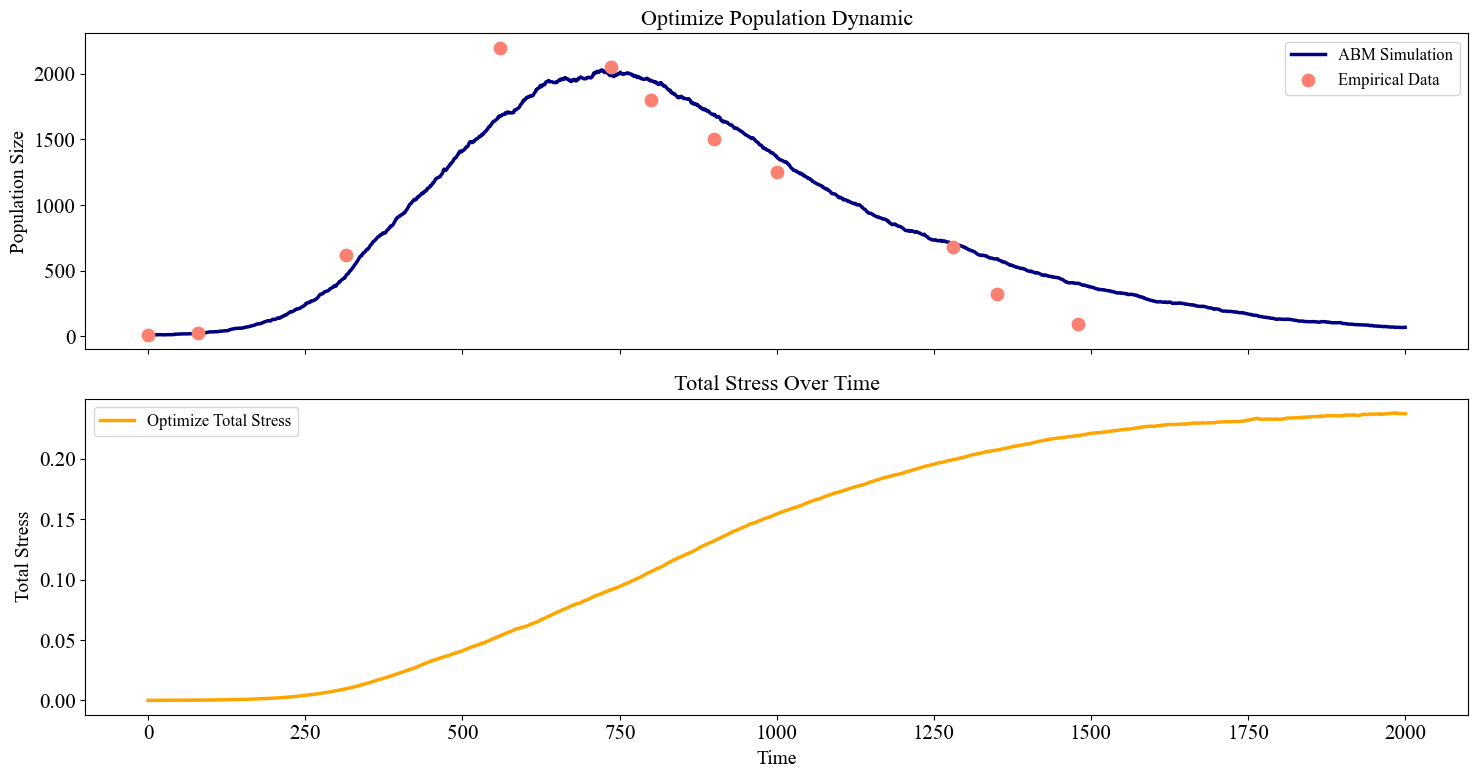

In [27]:
FIGSIZE = (15, 8)
LINEWIDTH = 2.5
MARKER_SIZE = 80
FONT_SIZE = 14

COLOR_EBM = "navy"
COLOR_ED = "salmon"
COLOR_STRESS = "orange"

TITLE_SIZE = 16
LABEL_SIZE = 14
LEGEND_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE
})

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax = axes[0]
ax.plot(P_ts_ABM, label="ABM Simulation", color=COLOR_EBM, linewidth=LINEWIDTH)
ax.scatter(t_ED, p_ED, label="Empirical Data", color=COLOR_ED, s=MARKER_SIZE, zorder=3)
ax.set_ylabel("Population Size")
ax.set_title("Optimize Population Dynamic")
ax.legend()

ax = axes[1]
ax.plot(S_ts_ABM, label="Optimize Total Stress", color=COLOR_STRESS, linewidth=LINEWIDTH)
ax.set_ylabel("Total Stress")
ax.set_xlabel("Time")
ax.set_title("Total Stress Over Time")
ax.legend()

plt.tight_layout()
plt.show()

In [28]:
NUM_SIM = sims_u25.shape[0]

t_u25 = np.arange(sims_u25.shape[1], dtype=float)
idx_u25 = np.arange(NUM_SIM)

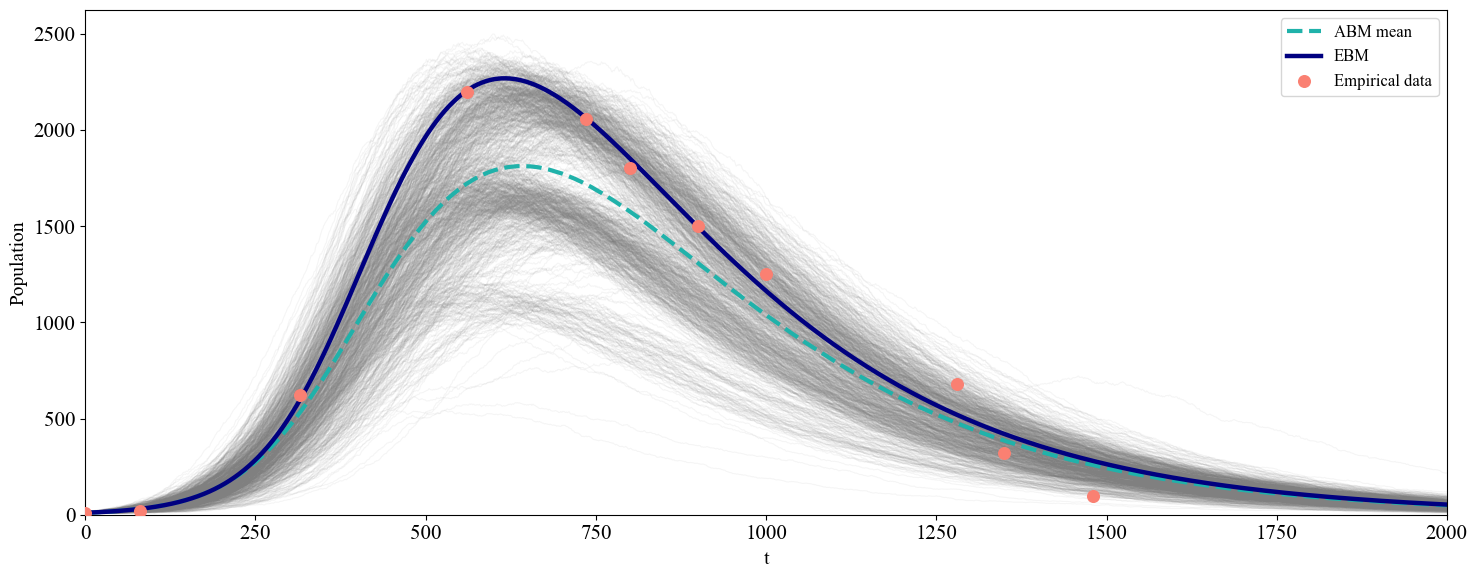

In [ ]:
mean_u25 = np.nanmean(sims_u25, axis=0)
t_u25 = np.arange(sims_u25.shape[1], dtype=float)

fig, ax = plt.subplots(figsize=(15, 6))

# spaghetti ABM (senza legenda)
for i in range(sims_u25.shape[0]):
    ax.plot(t_u25, sims_u25[i], color="grey", linewidth=0.8, alpha=0.08)

# media ABM
ax.plot(t_u25, mean_u25,
        color="lightseagreen",
        linewidth=3.0,
        linestyle="--",
        label="ABM mean")

# EBM
S_ebm_u25, P_ebm_u25 = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
P_ebm_u25 = np.asarray(P_ebm_u25, dtype=float)
t_ebm_u25 = np.arange(len(P_ebm_u25), dtype=float)

ax.plot(t_ebm_u25, P_ebm_u25,
        color="navy",
        linewidth=3.2,
        label="EBM")

ax.scatter(t_ED, p_ED,
           color="salmon",
           s=70,
           zorder=5,
           label="Empirical data")

ax.legend()

ax.set_xlabel("t")
ax.set_ylabel("Population")
ax.set_ylim(bottom=0)
ax.set_xlim(0, max(t_u25.max(), t_ebm_u25.max()))

plt.tight_layout()
plt.show()

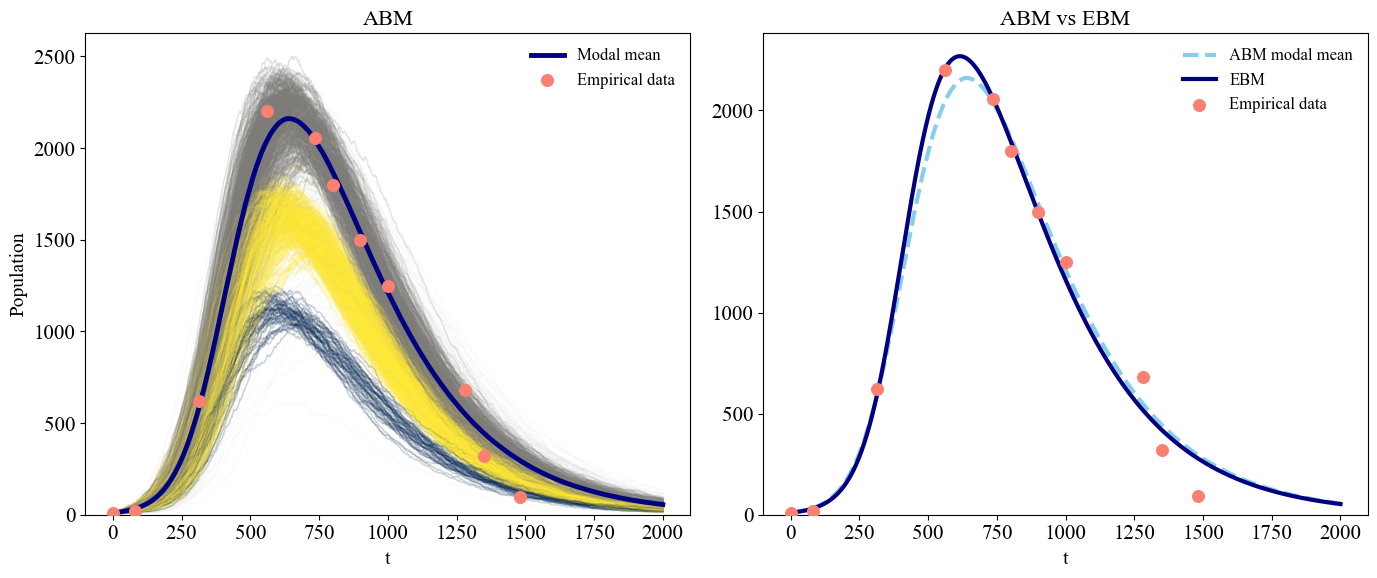

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== STYLE =====
NOISE_COLOR = "lightgrey"
NOISE_ALPHA = 0.1

CLUSTER_ALPHA = 0.2
CMAP = plt.cm.cividis

MODAL_COLOR = "navy"
MODAL_LW = 3.5

ABM_COLOR = "skyblue"
ABM_LS = "--"

EBM_COLOR = "navy"

EMP_COLOR = "salmon"

# ===== LOAD =====
all_data = pd.read_csv("all_data.csv")
clusters = pd.read_csv("clusters.csv")
nrmse = pd.read_csv("NRMSE_param_variation.csv")

# ===== BEST (variation = 0) =====
best = nrmse[nrmse["variation"] == 0].sort_values("NRMSE").iloc[0]
p, v = best["parameter"], best["variation"]

# ===== ABM =====
g = all_data[(all_data["param"] == p) & (all_data["variation"] == v)]
pivot = g.pivot(index="t", columns="id", values="population").sort_index()

t = pivot.index.to_numpy(float)
pivot.columns = pivot.columns.astype(str)

labs = clusters[(clusters["param"] == p) & (clusters["variation"] == v)].copy()
labs["id"] = labs["id"].astype(str)
labs = labs[labs["id"].isin(pivot.columns)]

counts = labs[labs["cluster"] != -1]["cluster"].value_counts()
modal = counts.idxmax() if len(counts) else None
modal_ids = labs["id"] if modal is None else labs[labs["cluster"] == modal]["id"]

mean = pivot[modal_ids].mean(axis=1).to_numpy(float)

# ===== EBM =====
_, P_ebm = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
P_ebm = np.asarray(P_ebm, float)
t_ebm = np.arange(len(P_ebm))

# ===== FIG =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: ABM + clusters ---
clust_ids = sorted([c for c in labs["cluster"].unique() if c != -1])
colors = {c: CMAP(i / max(1, len(clust_ids)-1)) for i, c in enumerate(clust_ids)}

for i in pivot.columns:
    y = pivot[i].to_numpy(float)
    row = labs[labs["id"] == i]["cluster"]
    if len(row) == 0 or row.iloc[0] == -1:
        ax1.plot(t, y, color=NOISE_COLOR, alpha=NOISE_ALPHA, lw=0.8)
    else:
        ax1.plot(t, y, color=colors[row.iloc[0]], alpha=CLUSTER_ALPHA, lw=1)

ax1.plot(t, mean, color=MODAL_COLOR, lw=MODAL_LW, label="Modal mean")
ax1.scatter(t_ED, p_ED, color=EMP_COLOR, s=70, zorder=5, label="Empirical data")

ax1.set_title("ABM")
ax1.set_xlabel("t")
ax1.set_ylabel("Population")
ax1.set_ylim(bottom=0)

# legenda sinistra
ax1.legend(frameon=False)

# --- RIGHT: ABM vs EBM ---
ax2.plot(t, mean, color=ABM_COLOR, ls=ABM_LS, lw=3, label="ABM modal mean")
ax2.plot(t_ebm, P_ebm, color=EBM_COLOR, lw=3, label="EBM")
ax2.scatter(t_ED, p_ED, color=EMP_COLOR, s=70, zorder=5, label="Empirical data")

ax2.set_title("ABM vs EBM")
ax2.set_xlabel("t")
ax2.set_ylim(bottom=0)

# legenda destra
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

In [36]:
# ===== EBM =====
ebm_df = pd.read_csv("best_fit_ebm.csv")
nrmse_ebm = ebm_df["RMSE_EBM"].iloc[0]

# ===== ABM =====
abm_df = pd.read_csv("NRMSE_param_variation.csv")
abm_best = abm_df[abm_df["variation"] == 0].sort_values("NRMSE").iloc[0]

nrmse_abm = abm_best["NRMSE"]
best_param = abm_best["parameter"]

print(f"EBM NRMSE: {nrmse_ebm:.4f}")
print(f"ABM NRMSE: {nrmse_abm:.4f}")

EBM NRMSE: 0.0391
ABM NRMSE: 0.0450


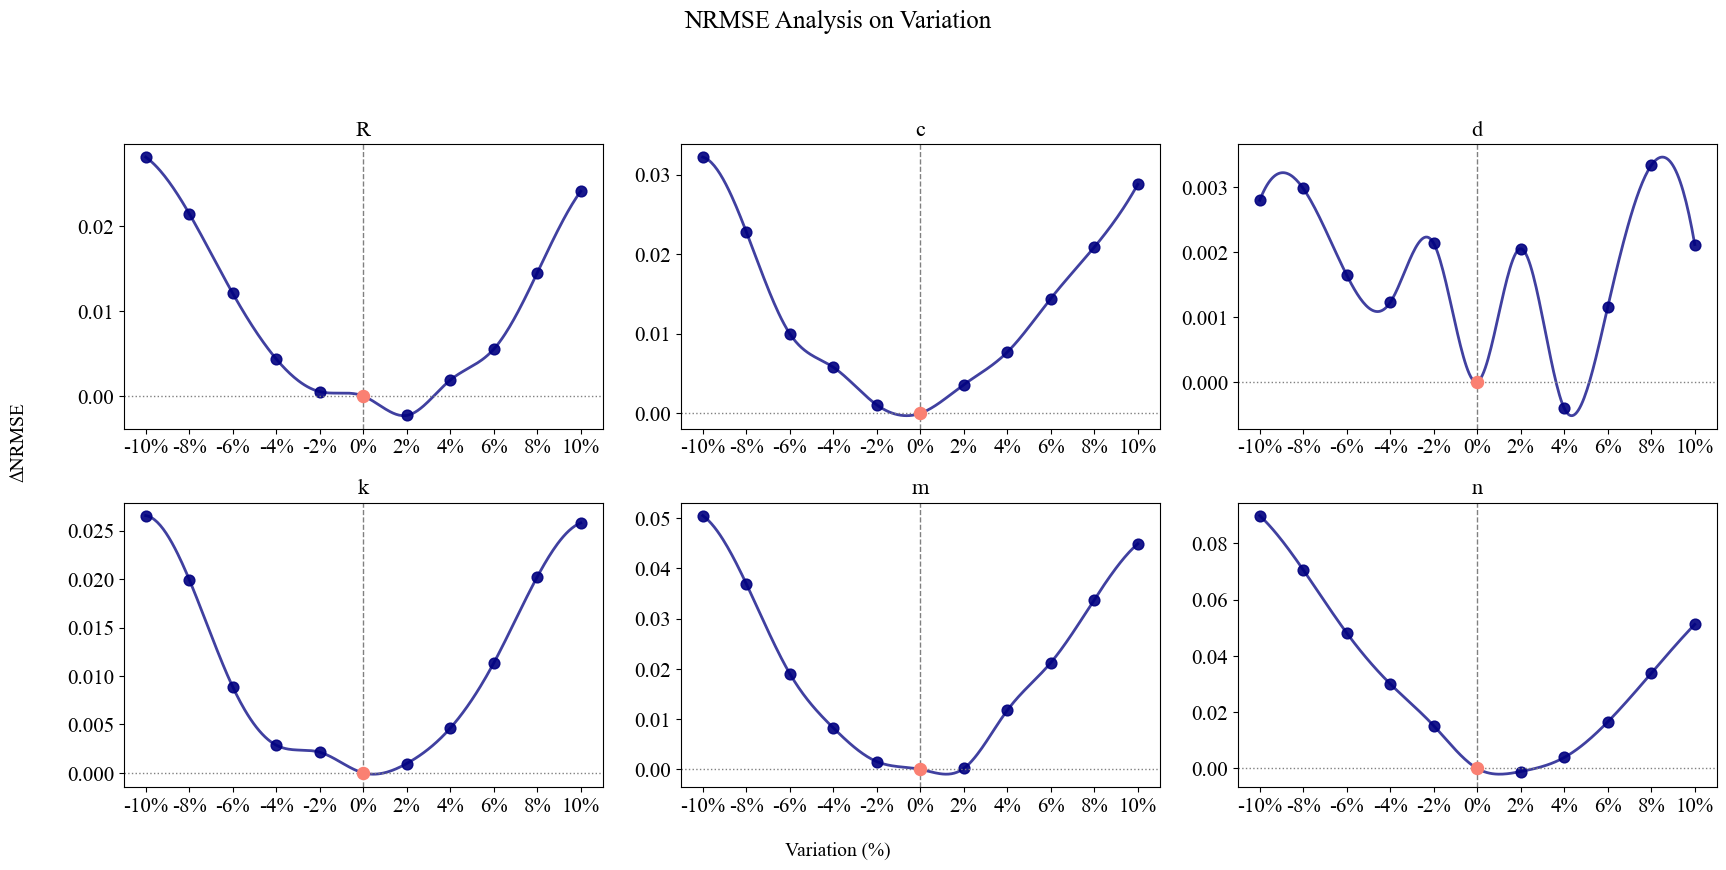

In [30]:
smooth = True

def parse_variation(v):
    v = str(v).strip()

    if v == "p00":
        return 0
    if v.startswith("p") and v[1:].isdigit():
        return int(v[1:])
    if v.startswith("m") and v[1:].isdigit():
        return -int(v[1:])

    try:
        return float(v)
    except ValueError:
        return np.nan

# ===== STYLE =====
POINT_COLOR = "navy"
BASELINE_POINT_COLOR = "salmon"
LINE_COLOR = "navy"

POINT_SIZE = 60
BASELINE_POINT_SIZE = 75
LINE_WIDTH = 2.0

POINT_ALPHA = 0.9
BASELINE_POINT_ALPHA = 1.0
LINE_ALPHA = 0.75

TITLE = "NRMSE Analysis on Variation"

# ===== DATA =====
df = pd.read_csv("NRMSE_param_variation.csv")
df["parameter"] = df["parameter"].astype(str).str.strip()
df["variation_num"] = df["variation"].map(parse_variation)
df["NRMSE"] = pd.to_numeric(df["NRMSE"], errors="coerce")

params = ["R", "c", "d", "k", "m", "n"]
params = [p for p in params if p in df["parameter"].unique()]

ncols = 3
nrows = math.ceil(len(params) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, param in zip(axes, params):
    sub = df[df["parameter"] == param].copy()
    sub = sub.dropna(subset=["variation_num", "NRMSE"])
    sub = sub.sort_values("variation_num")

    x = sub["variation_num"].to_numpy(dtype=float)
    y = sub["NRMSE"].to_numpy(dtype=float)

    baseline = sub.loc[sub["variation_num"] == 0, "NRMSE"]
    y0 = baseline.iloc[0] if len(baseline) > 0 else 0.0
    y = y - y0

    if len(x) >= 3 and smooth:
        xs = np.linspace(x.min(), x.max(), 300)
        ys = make_interp_spline(x, y, k=min(3, len(x) - 1))(xs)
        ax.plot(xs, ys, color=LINE_COLOR, linewidth=LINE_WIDTH, alpha=LINE_ALPHA)
    else:
        ax.plot(x, y, color=LINE_COLOR, linewidth=LINE_WIDTH, alpha=LINE_ALPHA)

    mask0 = x == 0
    mask_not0 = x != 0

    ax.scatter(x[mask_not0], y[mask_not0],
               s=POINT_SIZE, color=POINT_COLOR, alpha=POINT_ALPHA)

    ax.scatter(x[mask0], y[mask0],
               s=BASELINE_POINT_SIZE, color=BASELINE_POINT_COLOR,
               alpha=BASELINE_POINT_ALPHA, zorder=5)

    ax.axvline(0, linestyle="--", linewidth=1, color="gray")
    ax.axhline(0, linestyle=":", linewidth=1, color="gray")

    ax.set_title(param)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(v)}%" for v in x])

for ax in axes[len(params):]:
    ax.axis("off")

# ===== LABEL GLOBALI =====
fig.suptitle(TITLE, fontsize=18)

fig.text(0.5, 0.04, "Variation (%)", ha="center", fontsize=14)
fig.text(0.04, 0.5, "ΔNRMSE", va="center", rotation="vertical", fontsize=14)

plt.tight_layout(rect=[0.06, 0.06, 1, 0.93])
plt.show()